In [1]:
# from LadrunoGraphStyle import set_default_plot_params, main_colors
# set_default_plot_params()

In [7]:
from fem import (
    # Core
    Material,
    # Sections
    Membrane,
    # Gmsh tools
    GMSHtools,
    # FEM builders
    plan, build_elements, build_load_vector,
    # Visualization — Gmsh
    add_element_data_view, add_node_data_view, compute_nodal_average,
    # Plotting — matplotlib
    plot_mesh, plot_field_2d, plot_deformed, plot_loads_2d, plot_gmsh_mesh,
    # Elements
    CST, LST, Quad4, Quad9,
    # Units
    kgf, tf, kN, MPa, GPa, kg, g, cm, m, mm,
    # Parameters
    globalParameters,
)

import os
import numpy as np
import matplotlib.pyplot as plt
import gmsh

np.set_printoptions(suppress=True, precision=6, linewidth=400)

In [3]:
globalParameters['nDoF'] = 2
globalParameters['nDIM'] = 2

In [4]:
# General model parameters

output_path = os.getcwd()
mesh_name = 'Cantiliverbeam'
output_file = os.path.join(output_path, mesh_name + '.msh')

if not os.path.exists(output_path):
    os.makedirs(output_path)

In [5]:
# # Generate the mesh
# gmsh.model.mesh.generate()
# # Save mesh to disk
# gmsh.write(output_file)
# # Open GMSH GUI
# gmsh.fltk.run()
# # Write mesh file again (redundant)
# v = gmsh.write(output_file)
# # Close GMSH instance
# gmsh.finalize()

In [8]:
fcp = 40*MPa
fct = 0.35*np.sqrt(fcp/MPa)*MPa
thickness = 1*m
rho = 2500 * kg/m**3

qload = (0.20*kN/mm)/(1*m)

#Constants
E_conc = 4700*np.sqrt(fcp/MPa)*MPa
nu_conc = 0.17

In [9]:
# Definimos el material
Concrete=Material(name='Concrete',
             E=E_conc,
             nu=nu_conc,
             rho=rho)

# Definimos una seccion de la membrana
Cantiliverbeam=Membrane(name='Cantiliverbeam',
                thickness=thickness,
                material=Concrete)

section_dictionary={10:Cantiliverbeam,
                        }


restrain_dictionary={8:['r', 'r']}



load_dictionary = {
    9:   {'value': qload, 'direction': '-y'},   # line load  [N/mm]
    258: {'value': -30,   'direction': 'y'},     # point load [N]
}


In [11]:
# Read mesh
mesh = GMSHtools(output_file)
node_map, system_nDof = plan(mesh, restrain_dictionary)


  MESH SUMMARY

  === NODES ===  (1606 total — showing first 3)
     Tag              x              y              z
--------------------------------------------------------------------------------
       1         0.0000         0.0000         0.0000
       2         0.0000      1600.0000         0.0000
       3       600.0000      1600.0000         0.0000
--------------------------------------------------------------------------------

  === PHYSICAL GROUPS ===  (3 total)
      ID    Dim   Name
--------------------------------------------------------------------------------
       8      1   'Emp'
       9      1   'q'
      10      2   'con'
--------------------------------------------------------------------------------

  === ELEMENTS ===  (3 groups)
      ID    Dim     Type   Nodes/el   N elements   Name
--------------------------------------------------------------------------------
       8      1        1          2           31   'Emp'
       9      1        1          2    

In [16]:
# Map number of nodes per element to element class
element_map = {
    3: CST,         # 3-node triangles
    4: Quad4,       # 4-node quadrilaterals
    6: LST,         # 6-node triangles
    9: Quad9,       # 9-node quadrilaterals
}

elements = build_elements(
    mesh               = mesh,
    node_map           = node_map,
    section_dictionary = section_dictionary,
    element_class_map  = element_map,
    load_dictionary    = load_dictionary,
    type               = 'planeStrain',
    sampling_points    = 3,
    eval_points        = [0, 0],
)

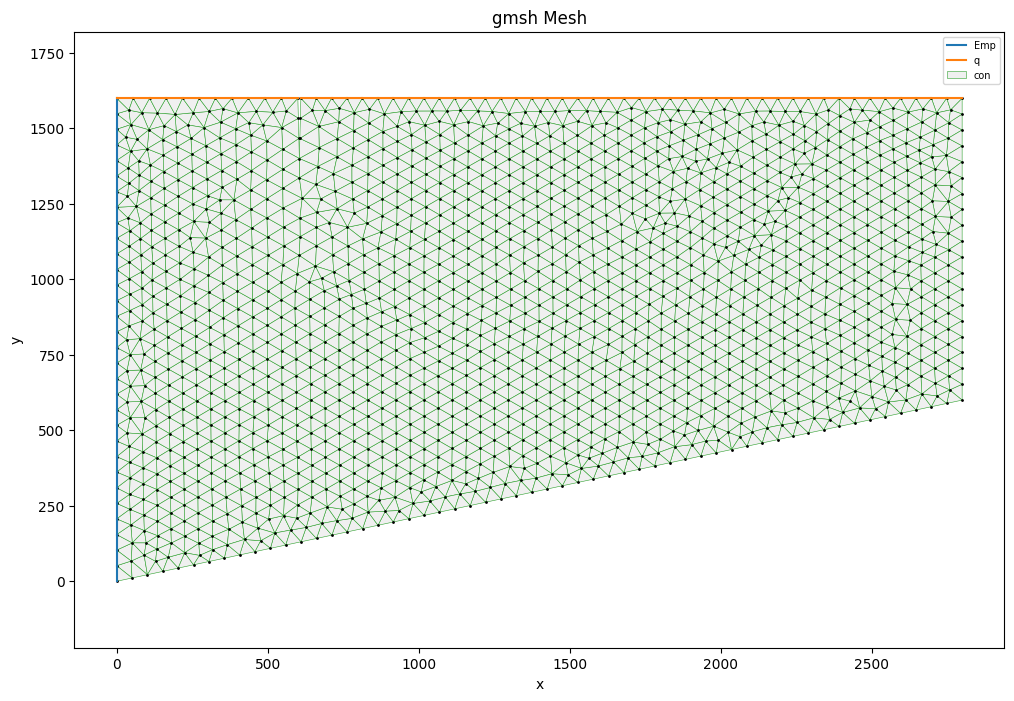

In [12]:
# %matplotlib widge
plot_gmsh_mesh(mesh,
               show_node_labels   = False,
               show_element_labels= False,
               show_node_points   = True,
            #    view_3d            = True,   elev= 45, azim= -45,
               figsize            = (12, 8))

In [18]:
# Build global nodal force vector from load dictionary = body + surface
F_load = np.zeros(system_nDof)
for elem in elements:
    F_load[elem.idx] += elem.F_fe_global

F_load += build_load_vector(mesh, node_map, load_dictionary, system_nDof)

In [19]:
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import spsolve

# Assembly
K = lil_matrix((system_nDof, system_nDof))
for element in elements:
    for i_local, i_global in enumerate(element.idx):
        for j_local, j_global in enumerate(element.idx):
            K[i_global, j_global] += element.kg[i_local, j_local]
K = K.tocsr()

# Force vector
F = np.zeros(system_nDof)
for node in node_map.values():
    F[node.idx] += node.nodalLoad
F += F_load

# DOF classification
dof_flags       = np.concatenate([node.restrain for node in node_map.values()])
free_dofs       = np.where(dof_flags == 'f')[0]
restrained_dofs = np.where(dof_flags == 'r')[0]

# Partitioning
Kff = K[free_dofs[:, None], free_dofs]
Kfr = K[free_dofs[:, None], restrained_dofs]
Krf = K[restrained_dofs[:, None], free_dofs]
Krr = K[restrained_dofs[:, None], restrained_dofs]

# Solution
ur = np.zeros(len(restrained_dofs))
uf = spsolve(Kff, F[free_dofs] - Kfr @ ur)

u = np.zeros(system_nDof)
u[free_dofs]       = uf
u[restrained_dofs] = ur

# Reactions
Rr = Krf @ uf + Krr @ ur
R  = np.zeros(system_nDof)
R[restrained_dofs] = Rr

In [20]:
def get_node(node_map, u, tag=None, x=None, y=None):
    """
    Returns a node by tag or by closest position and prints its displacements.
    Provide either tag or (x, y), not both.
    """
    if tag is not None:
        node = node_map[tag]
    else:
        best_tag  = None
        best_dist = np.inf
        for t, n in node_map.items():
            dist = np.linalg.norm(n.coordinates - np.array([x, y]))
            if dist < best_dist:
                best_dist = dist
                best_tag  = t
        node = node_map[best_tag]

    d = u[node.idx]
    print(f"Node {node.name} at {node.coordinates}:  ux={d[0]:+.6f}  uy={d[1]:+.6f}")
    return node

In [21]:
# By tag
node = get_node(node_map, u , tag=3)
# By position
node = get_node(node_map, u, x=1000, y=500)

Node 3 at [ 600. 1600.]:  ux=+0.020245  uy=-0.024732
Node 382 at [1018.141625  493.247321]:  ux=-0.022729  uy=-0.063608


In [23]:
# Reactions per node
for node in node_map.values():
    if any(r == 'r' for r in node.restrain):
        r = R[node.idx]
        print(f"Node {node.name}:  Rx={r[0]:+.6f}  Ry={r[1]:+.6f}")

# Equilibrium check
total_applied_x  = np.sum(F[0::2])
total_applied_y  = np.sum(F[1::2])
total_reaction_x = np.sum(R[0::2])
total_reaction_y = np.sum(R[1::2])
print('--' * 50)
print(f"Applied X:  {total_applied_x:+.4f}   Reaction X: {total_reaction_x:+.4f}   Balance: {total_applied_x + total_reaction_x:.4e}")
print(f"Applied Y:  {total_applied_y:+.4f}   Reaction Y: {total_reaction_y:+.4f}   Balance: {total_applied_y + total_reaction_y:.4e}")

Node 1:  Rx=+52438.073332  Ry=+21268.437003
Node 2:  Rx=-89493.822012  Ry=+23716.688227
Node 136:  Rx=-101493.176474  Ry=+27790.732913
Node 137:  Rx=-79557.187857  Ry=+25785.374698
Node 138:  Rx=-68885.241850  Ry=+25332.111306
Node 139:  Rx=-60742.482695  Ry=+23189.783163
Node 140:  Rx=-54872.478446  Ry=+22333.859437
Node 141:  Rx=-49849.994174  Ry=+20924.599236
Node 142:  Rx=-44788.564782  Ry=+18575.195173
Node 143:  Rx=-39888.522144  Ry=+18086.085818
Node 144:  Rx=-34657.312492  Ry=+16307.827341
Node 145:  Rx=-29364.431080  Ry=+15169.441602
Node 146:  Rx=-23846.828667  Ry=+14190.405095
Node 147:  Rx=-18233.749771  Ry=+13531.912759
Node 148:  Rx=-12521.900275  Ry=+12918.166083
Node 149:  Rx=-6758.559248  Ry=+12616.970686
Node 150:  Rx=-1014.239099  Ry=+12558.696172
Node 151:  Rx=+4711.649083  Ry=+12322.668250
Node 152:  Rx=+10537.639009  Ry=+12287.465395
Node 153:  Rx=+16184.265910  Ry=+12345.770013
Node 154:  Rx=+21892.089931  Ry=+12587.516661
Node 155:  Rx=+27461.947142  Ry=+12741.3

In [25]:
for node in node_map.values():
    fx = F_load[node.idx[0]]
    fy = F_load[node.idx[1]]
    if abs(fx) > 0 or abs(fy) > 0:
        print(f"Node {node.name} at {node.coordinates}:  Fx={fx:+.4f}  Fy={fy:+.4f}")

Node 1 at [0. 0.]:  Fx=+0.0000  Fy=-0.0011
Node 2 at [   0. 1600.]:  Fx=-0.0000  Fy=-5460.0018
Node 3 at [ 600. 1600.]:  Fx=-0.0000  Fy=-5460.0020
Node 4 at [ 605. 1400.]:  Fx=+0.0000  Fy=-0.0096
Node 5 at [ 610. 1600.]:  Fx=-0.0000  Fy=-5098.1182
Node 6 at [2800. 1600.]:  Fx=-0.0000  Fy=-5098.1179
Node 7 at [2800.  600.]:  Fx=+0.0000  Fy=-0.0018
Node 8 at [50.909091 10.909091]:  Fx=+0.0000  Fy=-0.0034
Node 9 at [101.818182  21.818182]:  Fx=+0.0000  Fy=-0.0042
Node 10 at [152.727273  32.727273]:  Fx=+0.0000  Fy=-0.0025
Node 11 at [203.636364  43.636364]:  Fx=+0.0000  Fy=-0.0029
Node 12 at [254.545455  54.545455]:  Fx=+0.0000  Fy=-0.0023
Node 13 at [305.454545  65.454545]:  Fx=+0.0000  Fy=-0.0019
Node 14 at [356.363636  76.363636]:  Fx=+0.0000  Fy=-0.0025
Node 15 at [407.272727  87.272727]:  Fx=+0.0000  Fy=-0.0030
Node 16 at [458.181818  98.181818]:  Fx=+0.0000  Fy=-0.0025
Node 17 at [509.090909 109.090909]:  Fx=+0.0000  Fy=-0.0025
Node 18 at [560. 120.]:  Fx=+0.0000  Fy=-0.0030
Node 19

In [27]:
# Check if any restrained node has load
for node in node_map.values():
    if any(r == 'r' for r in node.restrain):
        fy = F_load[node.idx[1]]
        if abs(fy) > 0:
            print(f"Node {node.name} at {node.coordinates}: restrained but has Fy={fy:+.4f}")

Node 1 at [0. 0.]: restrained but has Fy=-0.0011
Node 2 at [   0. 1600.]: restrained but has Fy=-5460.0018
Node 136 at [   0.       1548.387097]: restrained but has Fy=-0.0027
Node 137 at [   0.       1496.774194]: restrained but has Fy=-0.0023
Node 138 at [   0.      1445.16129]: restrained but has Fy=-0.0024
Node 139 at [   0.       1393.548387]: restrained but has Fy=-0.0028
Node 140 at [   0.       1341.935484]: restrained but has Fy=-0.0025
Node 141 at [   0.       1290.322581]: restrained but has Fy=-0.0023
Node 142 at [   0.       1238.709677]: restrained but has Fy=-0.0035
Node 143 at [   0.       1187.096774]: restrained but has Fy=-0.0024
Node 144 at [   0.       1135.483871]: restrained but has Fy=-0.0027
Node 145 at [   0.       1083.870968]: restrained but has Fy=-0.0027
Node 146 at [   0.       1032.258065]: restrained but has Fy=-0.0028
Node 147 at [  0.       980.645161]: restrained but has Fy=-0.0028
Node 148 at [  0.       929.032258]: restrained but has Fy=-0.0028
No

In [28]:
n_nodes    = len(node_map)
n_elements = len(elements)

# Prepare displacement, force and reaction arrays (3D format for Gmsh)
u_3d = np.zeros((n_nodes, 3))
F_3d = np.zeros((n_nodes, 3))
R_3d = np.zeros((n_nodes, 3))

for i, node in enumerate(node_map.values()):
    u_3d[i, 0] = u[node.idx[0]]
    u_3d[i, 1] = u[node.idx[1]]
    F_3d[i, 0] = F[node.idx[0]]
    F_3d[i, 1] = F[node.idx[1]]
    R_3d[i, 0] = R[node.idx[0]]
    R_3d[i, 1] = R[node.idx[1]]

# Node tags for Gmsh
node_tags = np.array([node.name for node in node_map.values()])

# Stress, strain and Von Mises
sigma_gmsh             = np.zeros((n_elements, 3))
epsilon_gmsh           = np.zeros((n_elements, 3))
sigma_principal_gmsh   = np.zeros((n_elements, 2))
epsilon_principal_gmsh = np.zeros((n_elements, 2))
von_mises_gmsh         = np.zeros(n_elements)
element_tags_list      = []

for i, element in enumerate(elements):
    results = element.get_results(u)
    sigma   = results['stress'].flatten()
    epsilon = results['strain'].flatten()

    sigma_gmsh[i, :]             = sigma
    epsilon_gmsh[i, :]           = epsilon
    sigma_principal_gmsh[i, :]   = results['principal_stress'].flatten()
    epsilon_principal_gmsh[i, :] = results['principal_strain'].flatten()

    sxx, syy, sxy     = sigma
    von_mises_gmsh[i] = np.sqrt(sxx**2 - sxx*syy + syy**2)
    element_tags_list.append(element.element_tag)

In [30]:

# VISUALIZE RESULTS IN GMSH


gmsh.initialize()
gmsh.open(output_file)

# Node tags already computed above
# node_tags = np.array([node.name for node in nodes_list])

# --- Nodal vector fields ---
# VectorType options:
# 1 → Line segments (simple lines)
# 2 → Arrows
# 3 → Pyramids
# 4 → 3D arrows
# 5 → Displacement (visually deforms mesh)
# 6 → Displacement with deformation

add_node_data_view("Displacements",
                   node_tags,
                   u_3d,
                   vector_type=5,
                   factor=5)

add_node_data_view("Applied Loads",
                   node_tags,
                   F_3d,
                   arrow_size_max=60,
                   arrow_size_min=20)

add_node_data_view("Reactions",
                   node_tags,
                   R_3d)

2

In [31]:
# Hide surface faces for better visualization
gmsh.option.setNumber("Mesh.SurfaceFaces", 0)

# --- Element-based stress fields ---
add_element_data_view("Stress Sxx", 
                      element_tags_list, 
                      sigma_gmsh[:, 0])

add_element_data_view("Stress Syy", 
                      element_tags_list,
                        sigma_gmsh[:, 1])

add_element_data_view("Stress Sxy", 
                      element_tags_list, 
                      sigma_gmsh[:, 2])

# --- Element-based strain fields ---
add_element_data_view("Strain Exx", 
                      element_tags_list, 
                      epsilon_gmsh[:, 0])

add_element_data_view("Strain Eyy", 
                      element_tags_list, 
                      epsilon_gmsh[:, 1])

add_element_data_view("Strain Exy",
                      element_tags_list, 
                      epsilon_gmsh[:, 2])

8

In [32]:
# --- Principal stresses ---
add_element_data_view("Principal Stress S1", 
                      element_tags_list, 
                      sigma_principal_gmsh[:, 0])

add_element_data_view("Principal Stress S2", 
                      element_tags_list, 
                      sigma_principal_gmsh[:, 1])

# --- Principal strains ---
add_element_data_view("Principal Strain E1", 
                      element_tags_list,
                        epsilon_principal_gmsh[:, 0])

add_element_data_view("Principal Strain E2", 
                      element_tags_list,
                        epsilon_principal_gmsh[:, 1])

12

In [33]:
# --- Von Mises stress ---
add_element_data_view("Von Mises Stress", 
                      element_tags_list, 
                      von_mises_gmsh)

13

In [35]:
# --- Nodal averaged stress fields ---
sxx_nodal = compute_nodal_average(elements, 
                                sigma_gmsh[:, 0],   
                                node_map.values())
add_node_data_view("Sxx Nodal Averaged",                 
                    node_tags, sxx_nodal)

# -----------------
syy_nodal = compute_nodal_average(elements, 
                                sigma_gmsh[:, 1],   
                                node_map.values())
add_node_data_view("Syy Nodal Averaged",                 
                    node_tags, syy_nodal)

# -----------------
sxy_nodal = compute_nodal_average(elements, 
                                sigma_gmsh[:, 2],   
                                node_map.values())
add_node_data_view("Sxy Nodal Averaged",                 
                    node_tags, sxy_nodal)

# -----------------
s1_nodal = compute_nodal_average(elements, 
                                sigma_principal_gmsh[:, 0],     
                                node_map.values())
add_node_data_view("Principal Stress S1 Nodal Averaged",
                     node_tags, s1_nodal)

# -----------------
s2_nodal = compute_nodal_average(elements, 
                                sigma_principal_gmsh[:, 1],     
                                node_map.values())
add_node_data_view("Principal Stress S2 Nodal Averaged",
                     node_tags, s2_nodal)

# -----------------
vm_nodal = compute_nodal_average(elements, 
                                von_mises_gmsh,     
                                node_map.values())
add_node_data_view("Von Mises Nodal Averaged",          
                     node_tags, vm_nodal)

# -----------------
exx_nodal = compute_nodal_average(elements, 
                                epsilon_gmsh[:, 0],     
                                node_map.values())
add_node_data_view("Strain Exx Averaged",                
                    node_tags, exx_nodal)

# -----------------
# Open Gmsh GUI
gmsh.fltk.run()
gmsh.finalize()

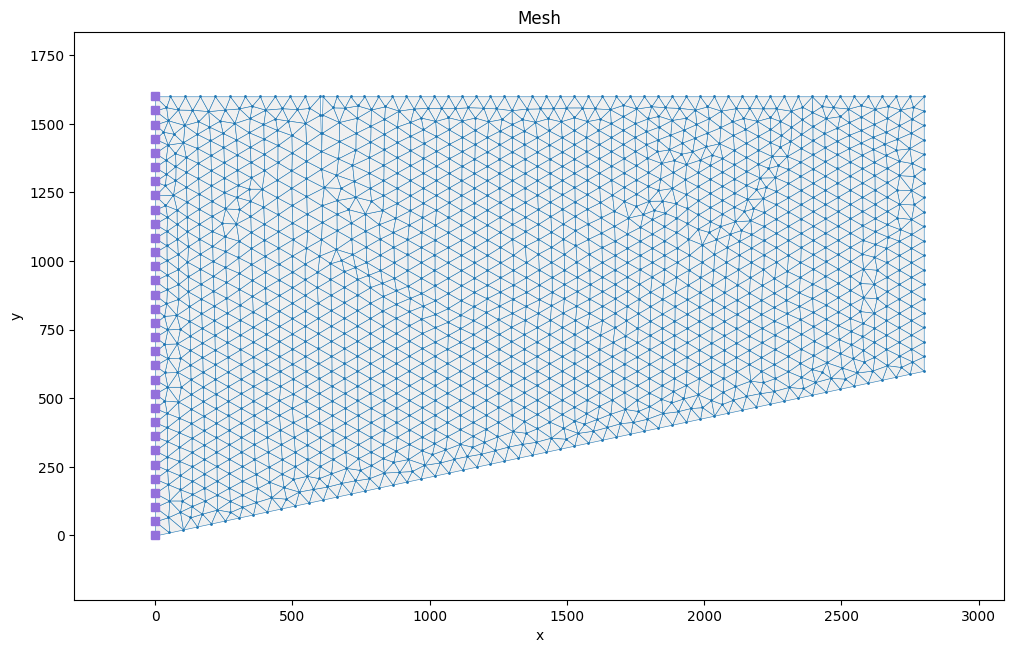

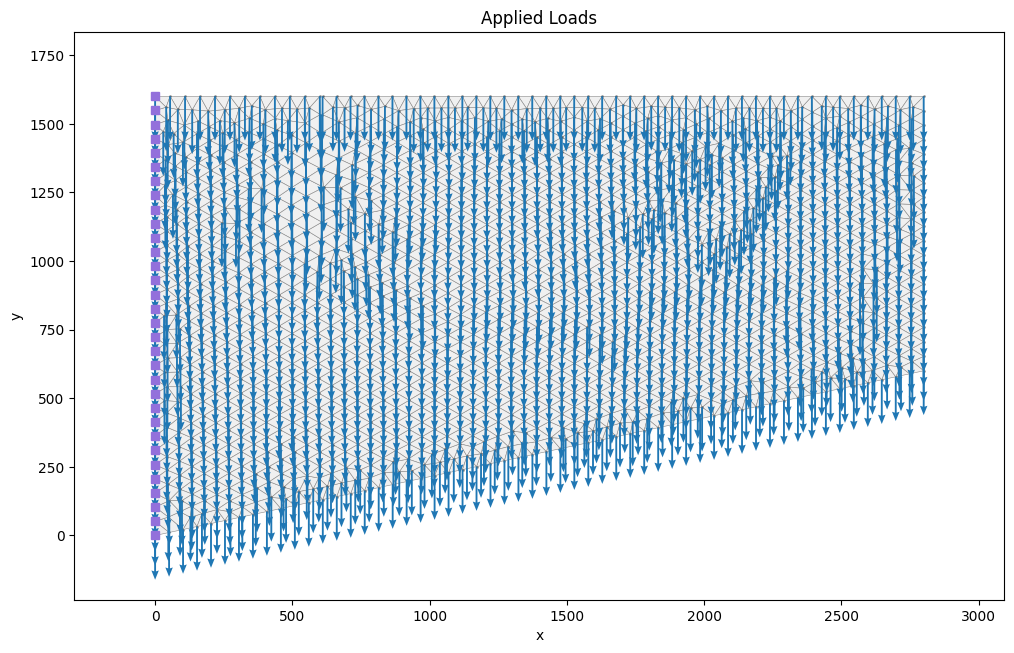

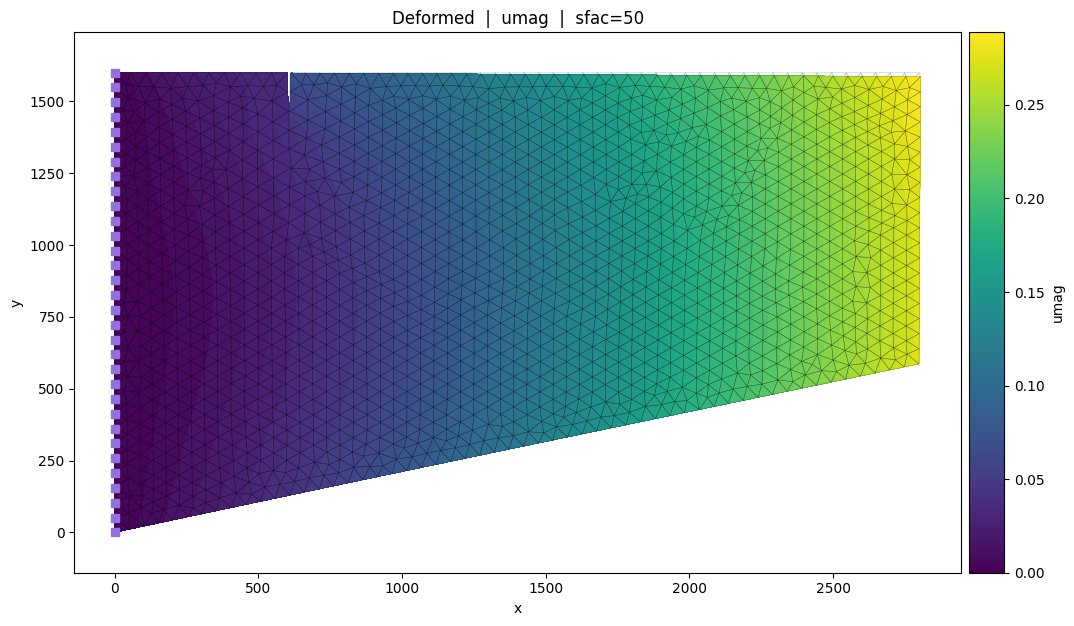

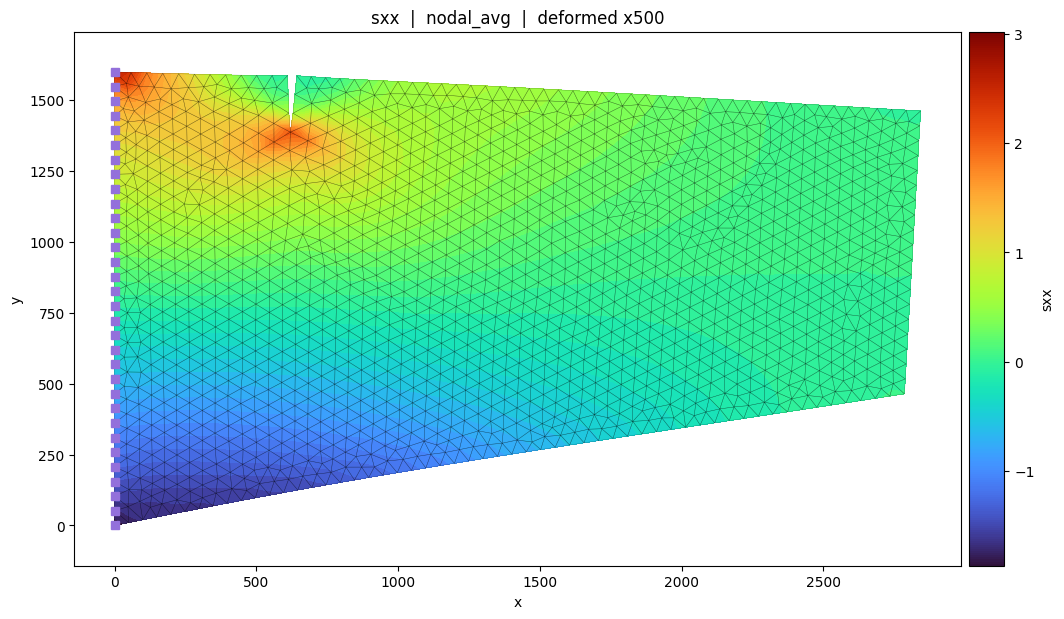

In [38]:
# Mesh
plot_mesh(
    nodes               = node_map.values(),
    elements            = elements,
    show_node_labels    = False,
    show_element_labels = False,
    show_supports       = True,
    show_element_edges  = True,
    show_node_points    = True,
    figsize             = (12, 12),
    ax                  = None,
    save                = None,
)

# Loads
plot_loads_2d(
    nodes               = node_map.values(),
    elements            = elements,
    F_load              = F_load,
    show_element_edges  = True,
    show_node_points    = True,
    show_supports       = True,
    figsize             = (12, 12),
    ax                  = None,
    save                = None,
)

# Deformed
plot_deformed(
    nodes               = node_map.values(),
    elements            = elements,
    u                   = u,
    component           = 'umag',   # 'ux', 'uy', 'umag'
    sfac                = 50,
    cmap                = 'viridis',
    limit               = None,
    show_element_edges  = True,
    show_node_points    = False,
    show_supports       = True,
    figsize             = (12, 12),
    ax                  = None,
    save                = None,
)

# Stress or Strain Field
plot_field_2d(
    nodes               = node_map.values(),
    elements            = elements,
    u                   = u,
    component           = 'sxx',       # 'sxx','syy','sxy','vmis','s1','s2','exx','eyy','exy','e1','e2'
    result_type         = 'nodal_avg', # 'nodal_avg' or 'element'
    deformed            = True,
    sfac                = 500,
    limit               = None,
    cmap                = 'turbo',
    show_element_edges  = True,
    show_node_points    = False,
    show_supports       = True,
    figsize             = (12, 12),
    ax                  = None,
    save                = None,
)

In [39]:
def get_node(node_map, u, tag=None, x=None, y=None):
    """
    Returns a node by tag or by closest position and prints its displacements.
    Provide either tag or (x, y), not both.
    """
    if tag is not None:
        node = node_map[tag]
    else:
        best_tag  = None
        best_dist = np.inf
        for t, n in node_map.items():
            dist = np.linalg.norm(n.coordinates - np.array([x, y]))
            if dist < best_dist:
                best_dist = dist
                best_tag  = t
        node = node_map[best_tag]

    d = u[node.idx]
    print(f"Node {node.name} at {node.coordinates}:  ux={d[0]:+.6f}  uy={d[1]:+.6f}")
    return node

# By tag
node = get_node(node_map, u , tag=3)
# By position
node = get_node(node_map, u, x=2500, y=500)

Node 3 at [ 600. 1600.]:  ux=+0.020245  uy=-0.024732
Node 56 at [2494.545455  534.545455]:  ux=-0.035139  uy=-0.235901


In [40]:
def get_element(elements, u, tag=None, x=None, y=None):
    """
    Returns an element by tag or by closest centroid position and prints its results.
    Provide either tag or (x, y), not both.
    """
    if tag is not None:
        elem = next((e for e in elements if e.element_tag == tag), None)
        if elem is None:
            print(f"Element tag={tag} not found.")
            return None
    else:
        best_elem = None
        best_dist = np.inf
        for e in elements:
            centroid = np.mean([n.coordinates for n in e.nodes], axis=0)
            dist     = np.linalg.norm(centroid - np.array([x, y]))
            if dist < best_dist:
                best_dist = dist
                best_elem = e
        elem = best_elem

    results  = elem.get_results(u)
    centroid = np.mean([n.coordinates for n in elem.nodes], axis=0)
    stress  = results['stress'].flatten()
    strain  = results['strain'].flatten()

    print(f"Element {elem.element_tag} at centroid {centroid}:")
    print(f"  stress : sxx={stress[0]:+.4f}  syy={stress[1]:+.4f}  sxy={stress[2]:+.4f}")
    print(f"  strain : exx={strain[0]:+.6f}  eyy={strain[1]:+.6f}  exy={strain[2]:+.6f}")

    return elem

# # By tag
# elem = get_element(elements, u, tag=10)

# By position
elem = get_element(elements, u, x=2500, y=0)

Element 3079 at centroid [2365.188246  516.764331]:
  stress : sxx=-0.0998  syy=-0.0110  sxy=-0.0319
  strain : exx=-0.000003  eyy=+0.000000  exy=-0.000003
